In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset 

In [2]:
train_file_path = "input/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
dataset_df = dataset_df.drop('Id', axis=1) # Drop the 'Id' column as it is not useful for prediction
print("Full train dataset shape is {}".format(dataset_df.shape))
dataset_df.dtypes[dataset_df.dtypes != 'object']

Full train dataset shape is (1460, 80)


MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

### House Prices Distribution

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


C:\Users\vaneg_wqyq\AppData\Local\Temp\ipykernel_3864\1325687398.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});


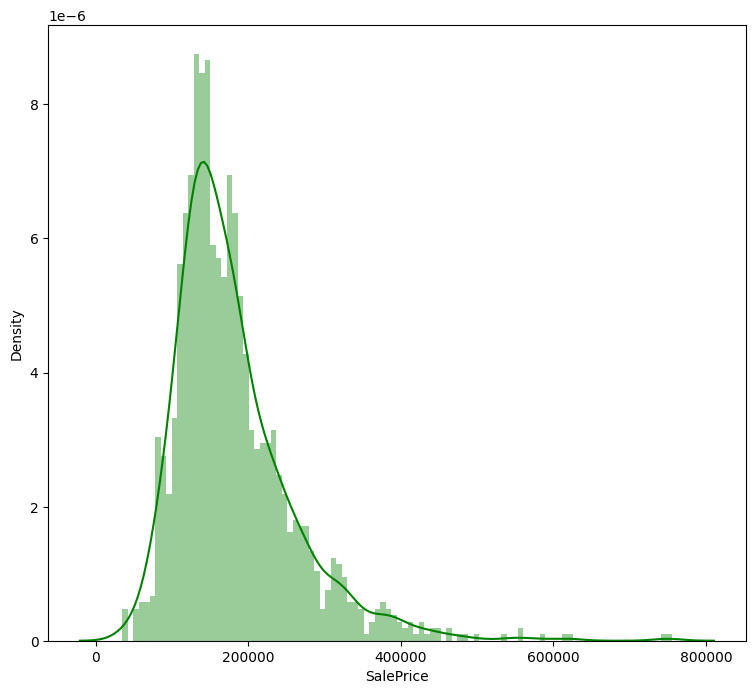

In [3]:
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});
#sns.histplot(dataset_df['SalePrice'], color='g', bins=100, alpha=0.4);

### Numerical data distribution

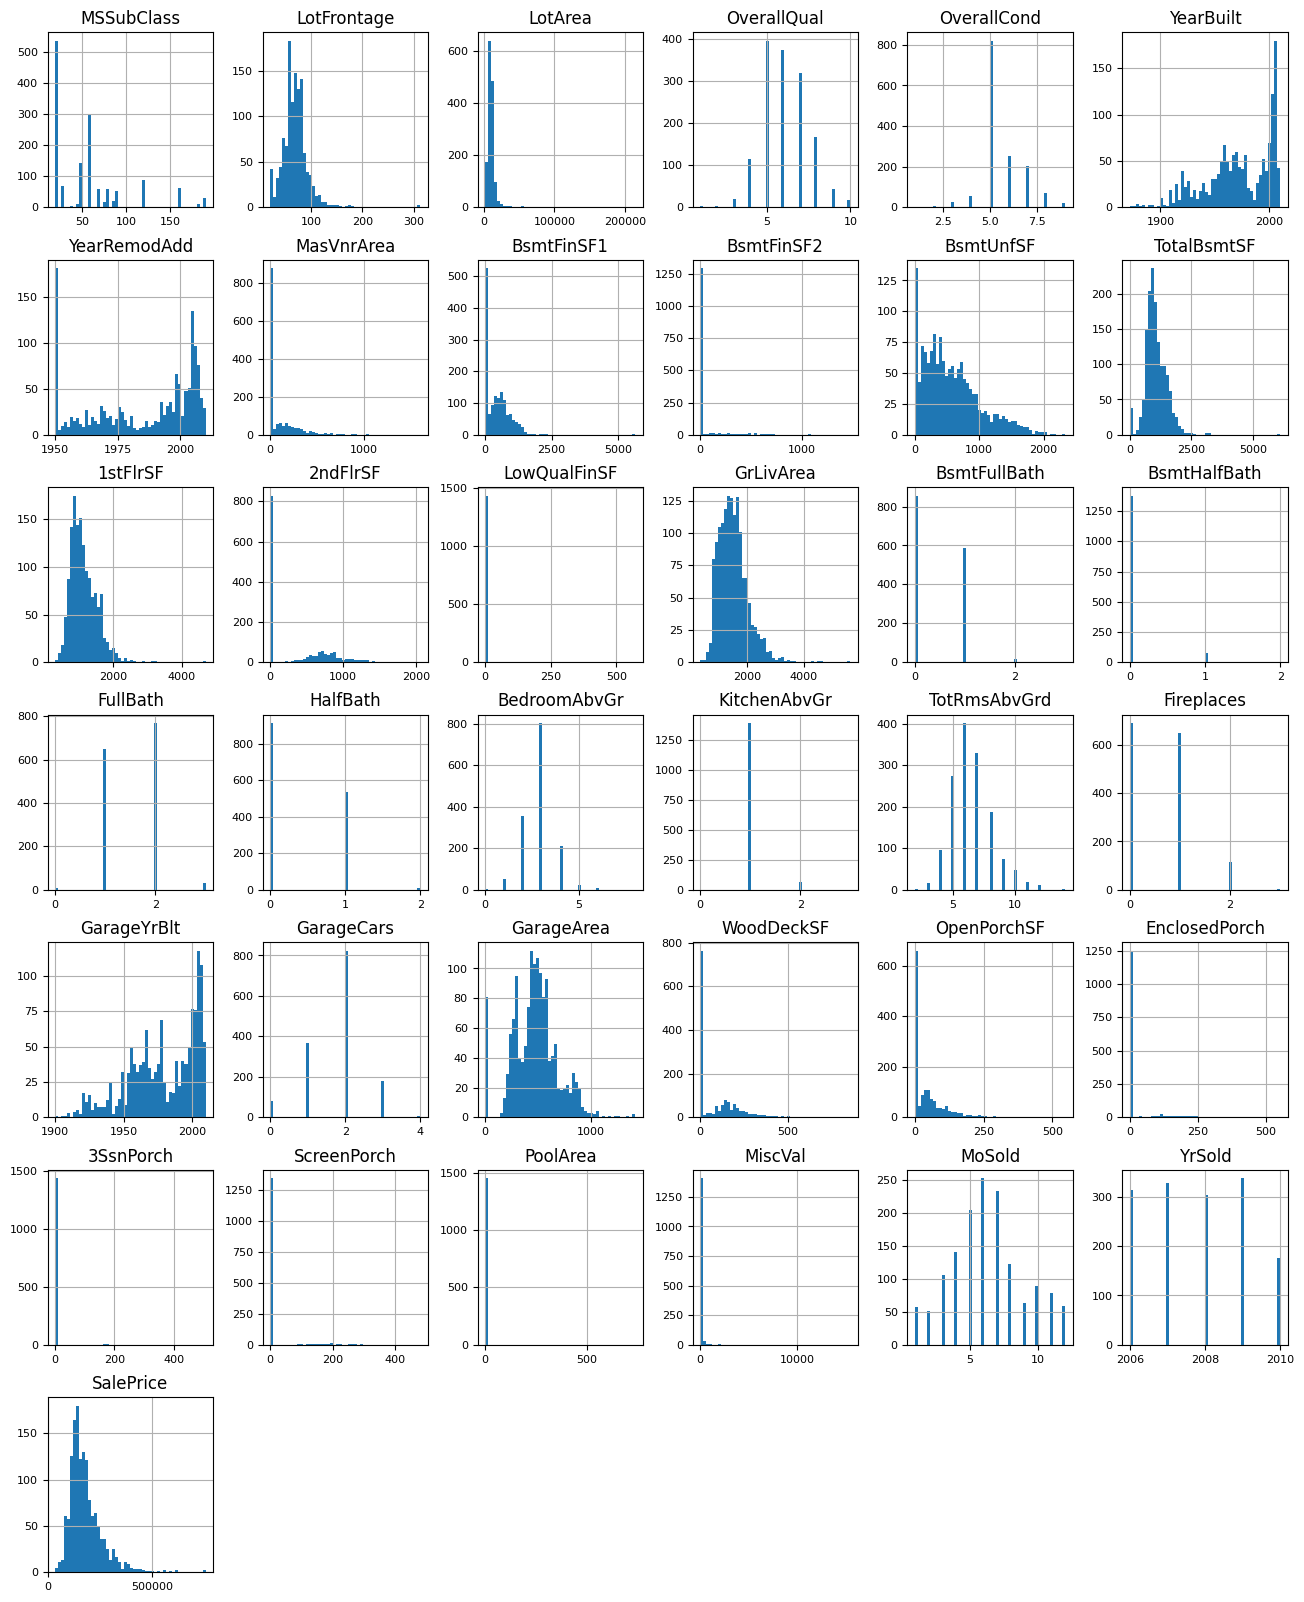

In [4]:
df_num = dataset_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

### Relationship with numerical variables

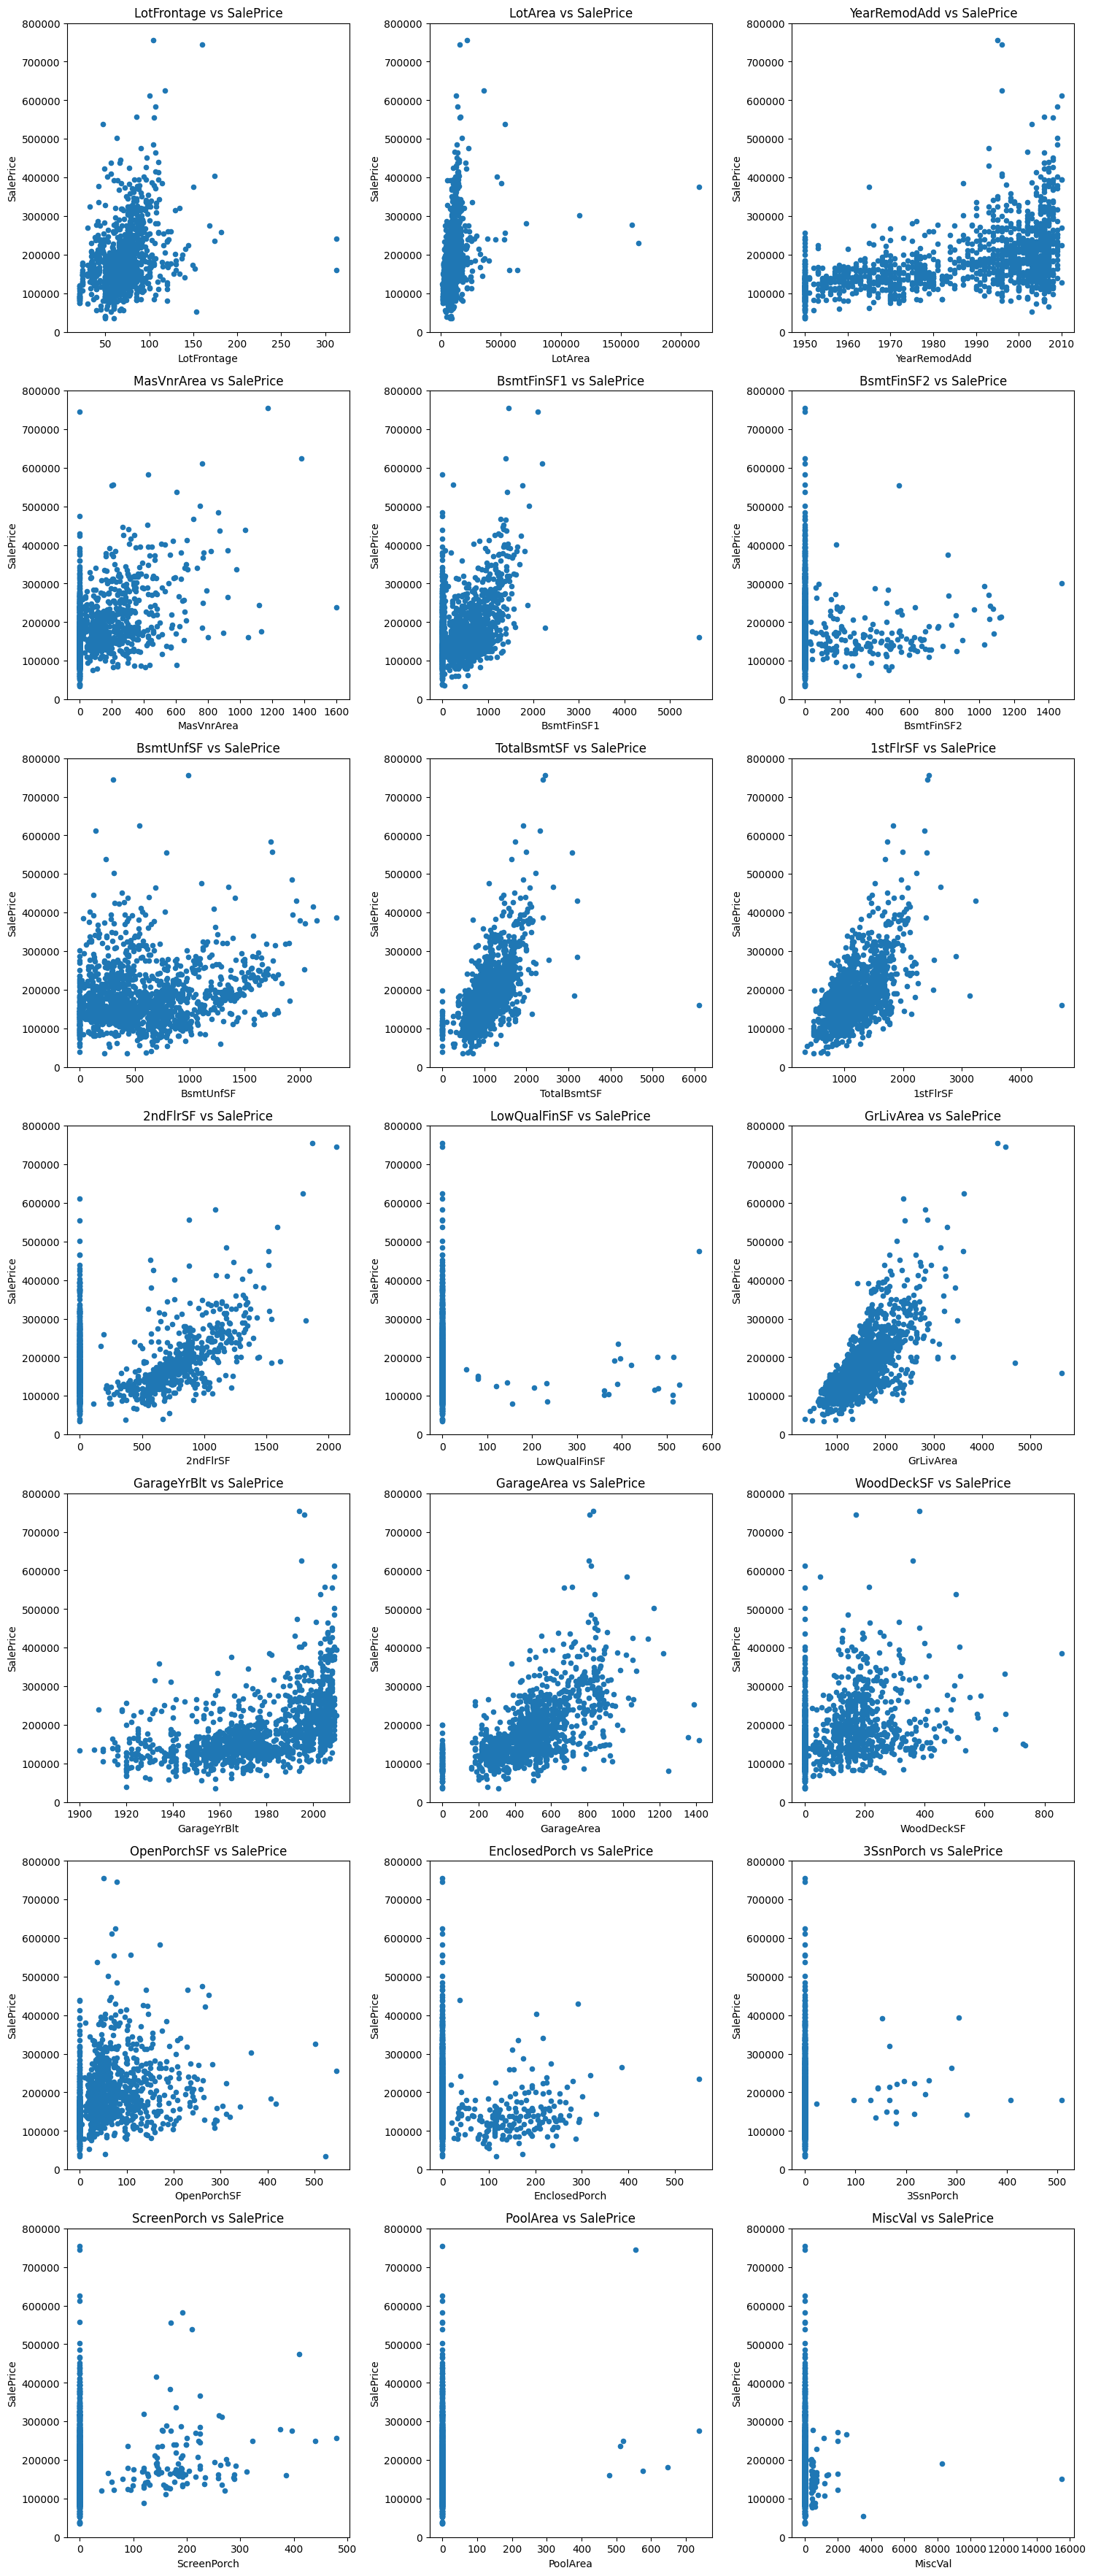

In [ ]:
# Scatter plots for all numerical variables against SalePrice
# Define categorical features to exclude from numerical analysis
categorical_features = ['MoSold', 'YrSold', 'GarageCars', 'Fireplaces', 'TotRmsAbvGrd', 
                       'KitchenAbvGr', 'BedroomAbvGr', 'HalfBath', 'FullBath', 
                       'BsmtHalfBath', 'BsmtFullBath', 'OverallCond', 'OverallQual', 'MSSubClass']

num_cols = df_num.columns.tolist()
# Remove SalePrice from the list to avoid plotting it against itself
if 'SalePrice' in num_cols:
    num_cols.remove('SalePrice')

# Remove categorical features from numerical columns
num_cols = [col for col in num_cols if col not in categorical_features]

# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([dataset_df['SalePrice'], dataset_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Relationship with categorical variables (Box plots)

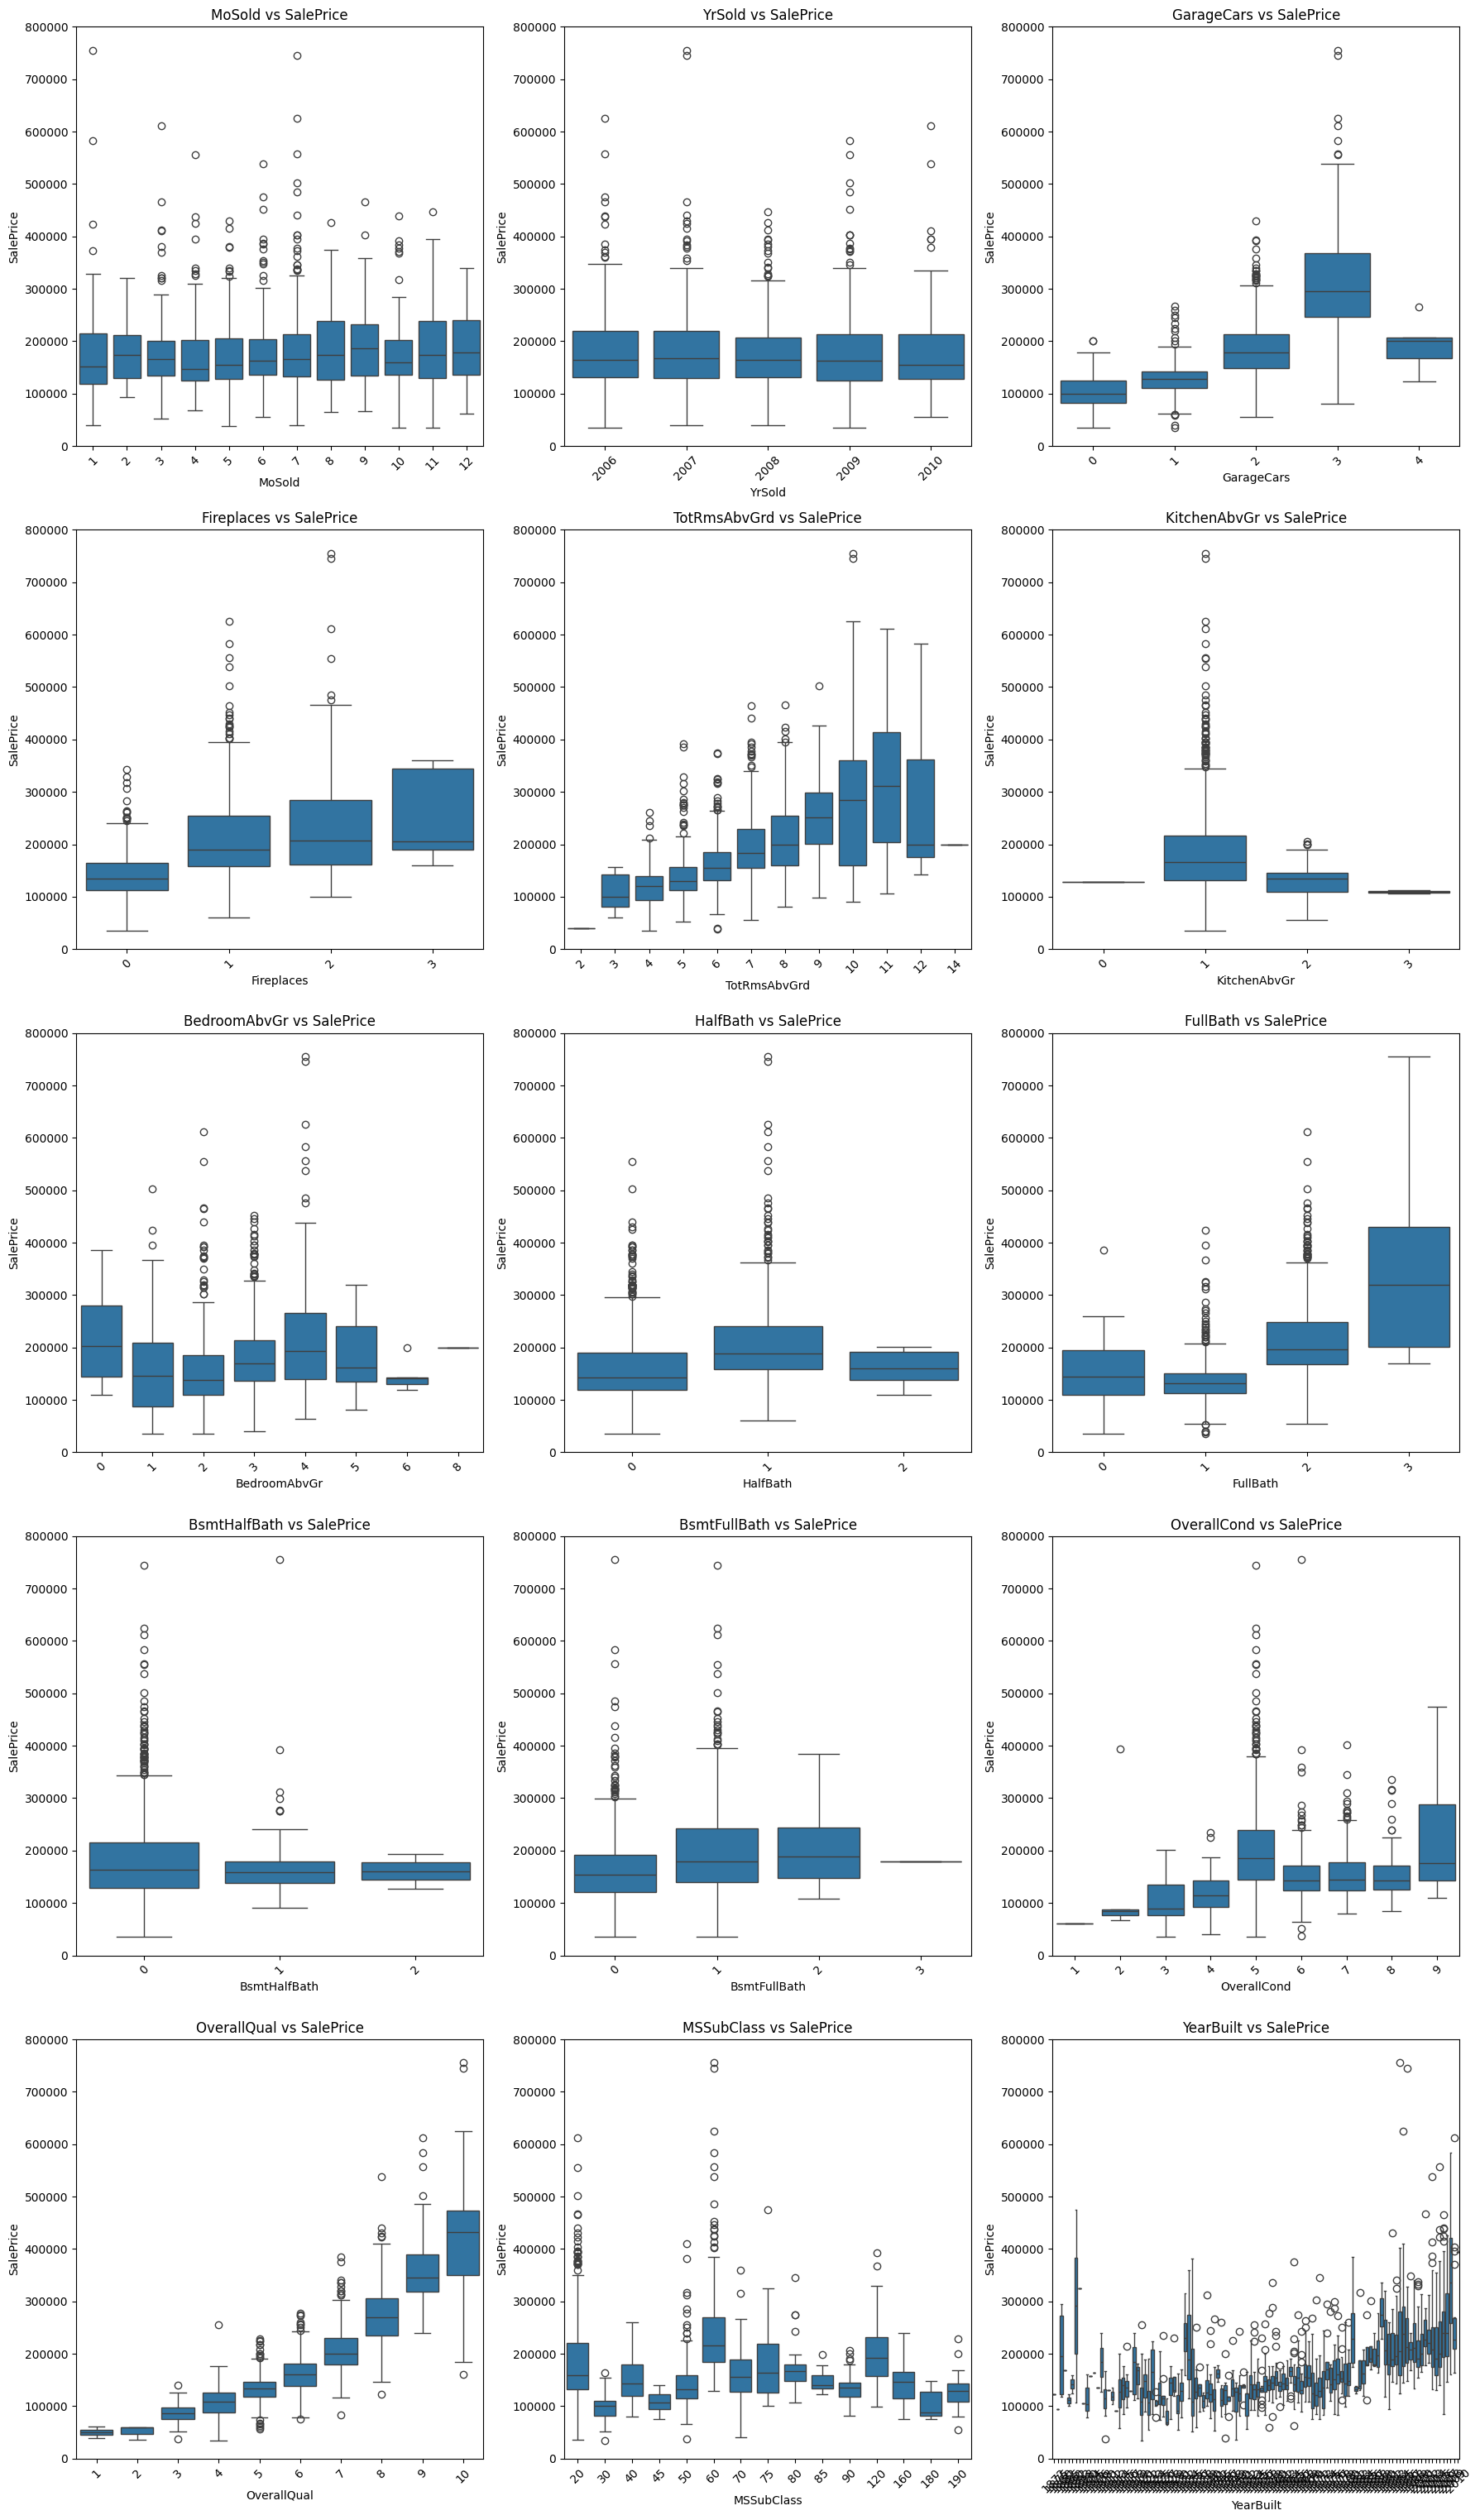

In [ ]:
# Filter categorical features that exist in the dataset
existing_categorical_features = [col for col in categorical_features if col in dataset_df.columns]

# Create subplots for box plots
fig, axes = plt.subplots(nrows=len(existing_categorical_features)//3 + 1, ncols=3, 
                        figsize=(18, 6*(len(existing_categorical_features)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(existing_categorical_features):
    data = pd.concat([dataset_df['SalePrice'], dataset_df[var]], axis=1)
    sns.boxplot(x=var, y="SalePrice", data=data, ax=axes[i])
    axes[i].set_ylim(0, 800000)
    axes[i].set_title(f'{var} vs SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()